# Health Risk Classification for Insurance Premium Optimization

## Problem Statement

Anova Insurance aims to optimize health insurance premium pricing by evaluating the health status of applicants. Health status plays an important role in:

*   Determining eligibility for insurance coverage.
*   Estimating premium amounts based on risk levels.

The objective of this project is to develop a machine learning classification model that predicts whether an applicant is:

*   **Healthy** (Target = 0)
*   **Unhealthy** (Target = 1)

using demographic, lifestyle, and medical information.

The resulting model can support data-driven insurance underwriting and risk assessment.

## Dataset Information

The dataset contains approximately 10,000 records and multiple health-related attributes including:

### Numerical Features
*   Age
*   BMI
*   Blood Pressure
*   Cholesterol
*   Glucose Level
*   Heart Rate
*   Sleep Hours
*   Exercise Hours
*   Water Intake
*   Stress Level

### Lifestyle and Medical Features
*   Smoking
*   Alcohol Consumption
*   Diet Quality
*   Mental Health Status
*   Physical Activity
*   Medical History
*   Allergies

### Target Variable
*   0 → Healthy
*   1 → Unhealthy

## Project Objectives
*   Understand the dataset and identify data quality issues.
*   Perform exploratory data analysis (EDA).
*   Handle missing values and anomalies.
*   Build classification models.
*   Evaluate model performance using appropriate metrics.
*   Identify the most influential health risk factors.

**Import Libraries**

In [36]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

**Load Dataset**

In [37]:
df = pd.read_csv("Healthcare_Data_Preprocessed_FIXED.csv")

df.head()

,Age,BMI,Blood_Pressure,Cholesterol,Glucose_Level,Heart_Rate,Sleep_Hours,Exercise_Hours,Water_Intake,Stress_Level,Target,Smoking,Alcohol,Diet,MentalHealth,PhysicalActivity,MedicalHistory,Allergies,Diet_Type_Vegan,Diet_Type_Vegetarian,Blood_Group_AB,Blood_Group_B,Blood_Group_O
0,37.0,26.0,111.0,198.0,99.0,72.0,5.5,1.7,1.6,4.4,1,2,2,1,2,1,0.0,1.0,False,True,True,False,False
1,37.0,24.0,121.0,199.0,103.0,75.0,4.5,1.9,2.6,5.6,1,0,1,1,2,1,2.0,2.0,False,False,True,False,False
2,81.0,27.0,NaN,NaN,100.0,74.0,12.1,2.9,2.6,1.8,0,2,1,2,0,0,1.0,0.0,True,False,False,False,False
3,25.0,21.0,150.0,199.0,102.0,70.0,4.3,1.0,1.7,5.2,0,2,0,1,2,1,2.0,0.0,True,False,False,True,False
4,24.0,26.0,146.0,202.0,99.0,76.0,16.0,5.0,3.4,1.4,0,0,1,2,0,2,0.0,2.0,False,True,False,True,False


**Initial Dataset Overview**

In [38]:
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Rows    : 10000
Columns : 23


In [39]:
# Random Samples
df.sample(5)

,Age,BMI,Blood_Pressure,Cholesterol,Glucose_Level,Heart_Rate,Sleep_Hours,Exercise_Hours,Water_Intake,Stress_Level,Target,Smoking,Alcohol,Diet,MentalHealth,PhysicalActivity,MedicalHistory,Allergies,Diet_Type_Vegan,Diet_Type_Vegetarian,Blood_Group_AB,Blood_Group_B,Blood_Group_O
4911,37.0,23.0,138.0,198.0,103.0,75.0,5.7,1.3,1.6,5.7,0,0,1,2,0,2,1.0,1.0,False,True,False,False,False
6261,37.0,28.0,149.0,199.0,102.0,78.0,5.6,1.1,1.7,5.4,0,0,2,1,1,1,2.0,0.0,True,False,False,False,False
4719,54.0,29.0,170.0,200.0,100.0,73.0,7.8,2.5,2.0,5.6,0,0,1,1,1,1,2.0,2.0,False,True,False,False,True
9804,57.0,28.0,137.0,200.0,99.0,73.0,8.4,2.7,2.6,4.9,0,0,0,1,1,0,0.0,2.0,True,False,False,False,True
7395,3.0,23.0,152.0,201.0,104.0,75.0,3.0,0.9,2.3,6.3,0,2,2,2,0,2,1.0,1.0,True,False,False,False,False


In [40]:
df.columns

Index(['Age', 'BMI', 'Blood_Pressure', 'Cholesterol', 'Glucose_Level',
       'Heart_Rate', 'Sleep_Hours', 'Exercise_Hours', 'Water_Intake',
       'Stress_Level', 'Target', 'Smoking', 'Alcohol', 'Diet', 'MentalHealth',
       'PhysicalActivity', 'MedicalHistory', 'Allergies', 'Diet_Type_Vegan',
       'Diet_Type_Vegetarian', 'Blood_Group_AB', 'Blood_Group_B',
       'Blood_Group_O'],
      dtype='object')

# **Stage 1 — Data Audit**

**1.1 Dataset Structure**

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   10000 non-null  float64
 1   BMI                   10000 non-null  float64
 2   Blood_Pressure        9471 non-null   float64
 3   Cholesterol           9462 non-null   float64
 4   Glucose_Level         9486 non-null   float64
 5   Heart_Rate            10000 non-null  float64
 6   Sleep_Hours           10000 non-null  float64
 7   Exercise_Hours        10000 non-null  float64
 8   Water_Intake          10000 non-null  float64
 9   Stress_Level          10000 non-null  float64
 10  Target                10000 non-null  int64  
 11  Smoking               10000 non-null  int64  
 12  Alcohol               10000 non-null  int64  
 13  Diet                  10000 non-null  int64  
 14  MentalHealth          10000 non-null  int64  
 15  PhysicalActivity    

**1.2 Statistical Summary**

In [42]:
df.describe()

,Age,BMI,Blood_Pressure,Cholesterol,Glucose_Level,Heart_Rate,Sleep_Hours,Exercise_Hours,Water_Intake,Stress_Level,Target,Smoking,Alcohol,Diet,MentalHealth,PhysicalActivity,MedicalHistory,Allergies
count,10000.000000,10000.000000,9471.000000,9462.000000,9486.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,9465.000000,9479.000000
mean,40.228000,25.711500,130.922395,199.193934,100.154122,73.531400,8.005780,2.43173,2.477490,4.508820,0.499900,0.994500,0.992700,1.005500,0.99670,1.000600,1.001796,0.996308
std,24.350238,1.944594,27.807917,2.080687,2.205152,1.724329,4.205662,1.32928,0.634218,1.817407,0.500025,0.815681,0.816525,0.816172,0.82326,0.809979,0.813361,0.816251
min,0.000000,19.000000,22.000000,192.000000,93.000000,67.000000,0.000000,0.00000,0.600000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,25.000000,24.000000,114.000000,198.000000,99.000000,72.000000,5.000000,1.50000,2.000000,3.300000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,37.000000,26.000000,135.000000,199.000000,100.000000,74.000000,6.300000,2.00000,2.400000,4.800000,0.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000
75%,49.000000,27.000000,150.000000,200.000000,102.000000,75.000000,10.800000,3.30000,2.900000,5.800000,1.000000,2.000000,2.000000,2.000000,2.00000,2.000000,2.000000,2.000000
max,100.000000,32.000000,225.000000,207.000000,107.000000,80.000000,16.000000,5.00000,4.600000,10.000000,1.000000,2.000000,2.000000,2.000000,2.00000,2.000000,2.000000,2.000000


**1.3 Missing Value Analysis**

In [43]:
df.isnull().sum()

,0
Age,0
BMI,0
Blood_Pressure,529
Cholesterol,538
Glucose_Level,514
Heart_Rate,0
Sleep_Hours,0
Exercise_Hours,0
Water_Intake,0
Stress_Level,0


In [44]:
(df.isnull().sum() / len(df)) * 100

,0
Age,0.00
BMI,0.00
Blood_Pressure,5.29
Cholesterol,5.38
Glucose_Level,5.14
Heart_Rate,0.00
Sleep_Hours,0.00
Exercise_Hours,0.00
Water_Intake,0.00
Stress_Level,0.00


**1.4 Duplicate Records**

In [45]:
df.duplicated().sum()

np.int64(0)

**1.5 Target Analysis**

In [46]:
df["Target"].value_counts()

,count
Target,
0,5001
1,4999


In [47]:
df["Target"].value_counts(normalize=True) * 100

,proportion
Target,
0,50.01
1,49.99


**1.6 Age Investigation**

In [48]:
negative_age = [df["Age"][index] for index, value in enumerate(df["Age"]) if value <= 0]

print(f"Total count of Age <= 0: {len(negative_age)}")

print(f"Minimum age: {min(negative_age)}")

Total count of Age <= 0: 96
Minimum age: 0.0


In [49]:
df["Age"].value_counts().sort_index().head(10)

,count
Age,
0.0,96
1.0,83
2.0,76
3.0,105
4.0,80
5.0,103
6.0,104
7.0,90
8.0,109


# **Stage 2 — Exploratory Data Analysis (EDA)**

**2.1 Univariate Analysis**

**2.1.1 Numerical Features Analysis**

In [60]:
numerical_features = [
    'Age', 'BMI', 'Blood_Pressure', 'Cholesterol', 'Glucose_Level',
    'Heart_Rate', 'Sleep_Hours', 'Exercise_Hours', 'Water_Intake', 'Stress_Level'
]

# Calculate the number of rows and columns for the subplots
num_features = len(numerical_features)
num_cols = 3  # You can adjust this number
num_rows = (num_features + num_cols - 1) // num_cols

**Histogram**

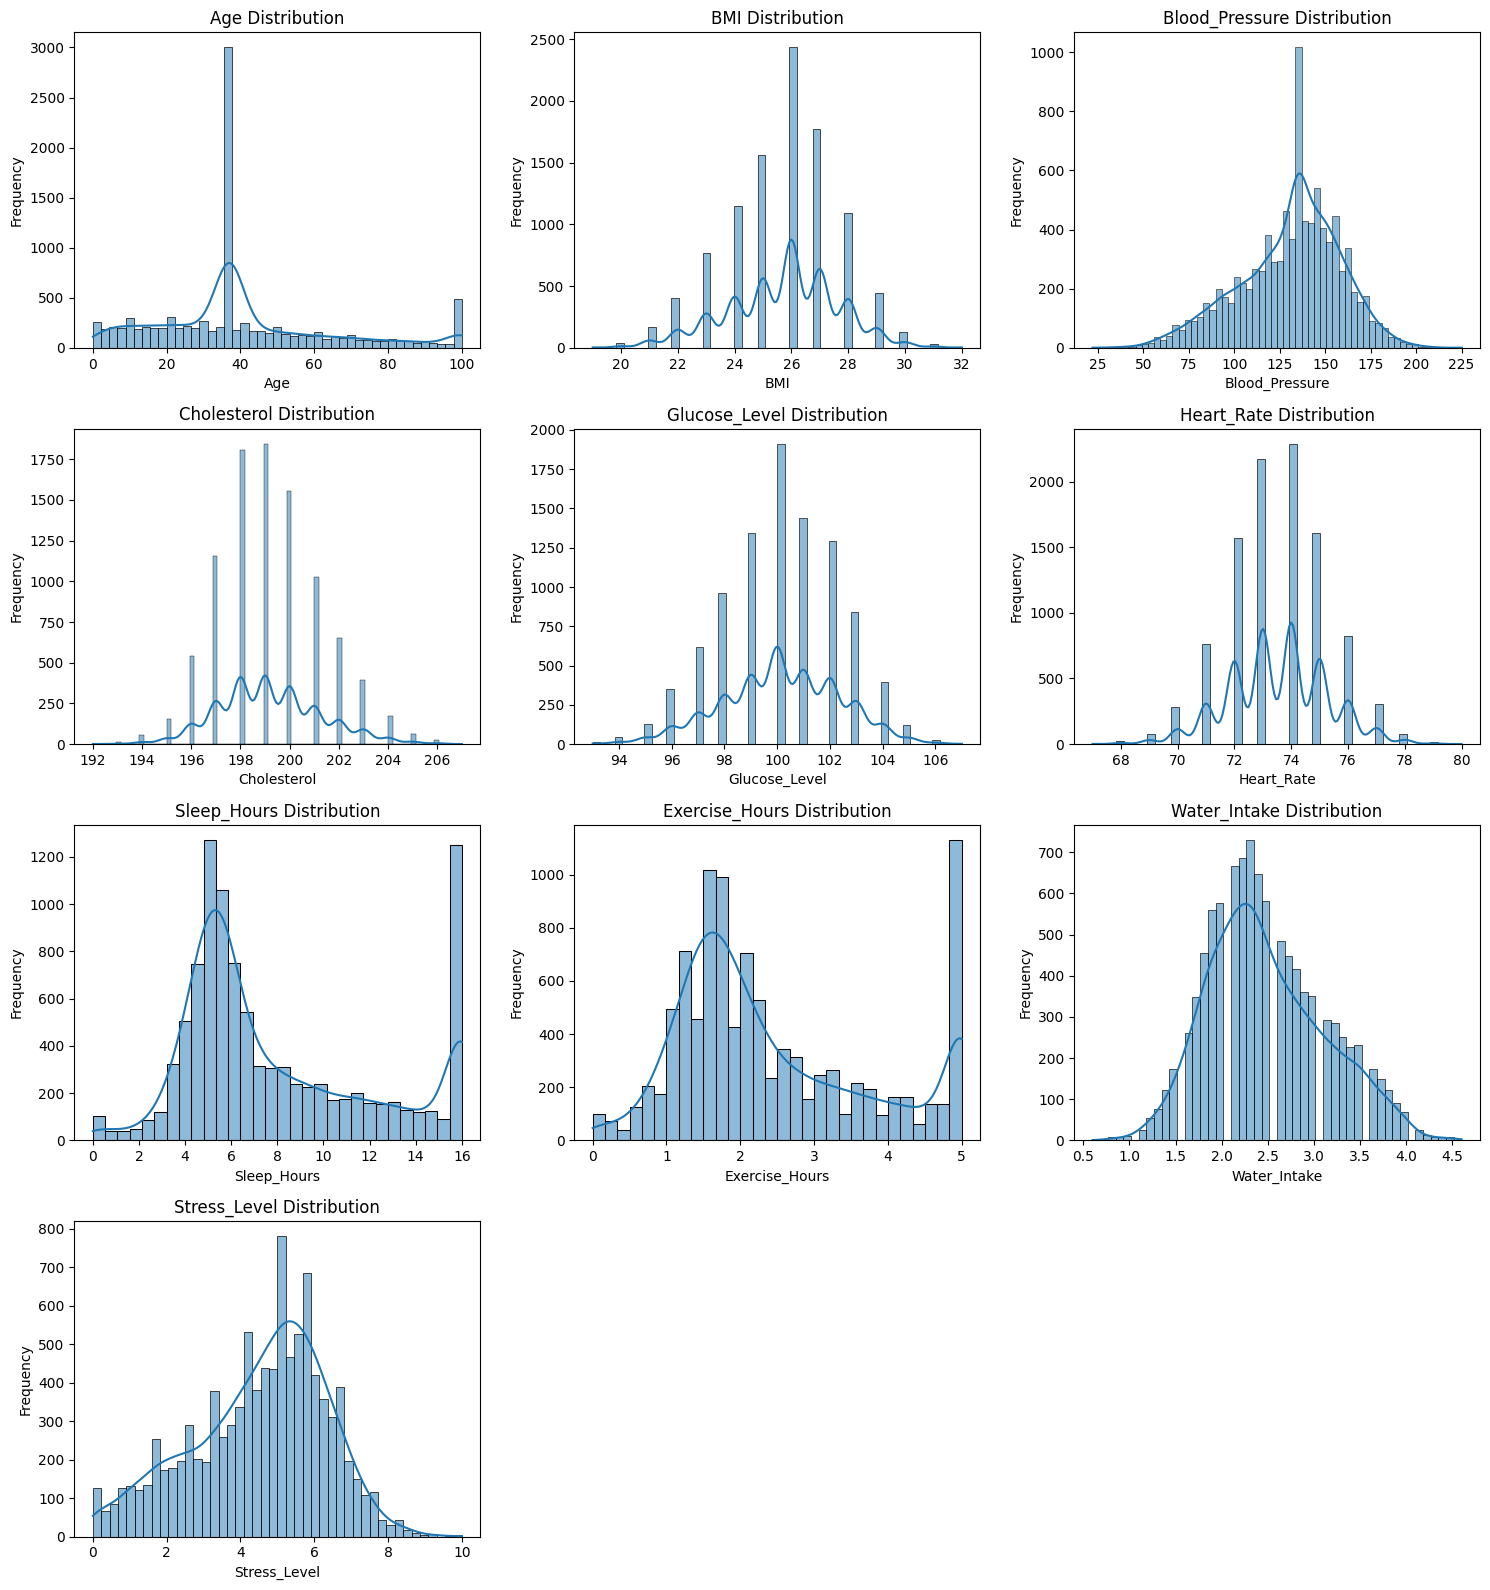

In [59]:
plt.figure(figsize=(num_cols * 5, num_rows * 4))

for i, col in enumerate(numerical_features):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'{col} Distribution')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

**Boxplot**

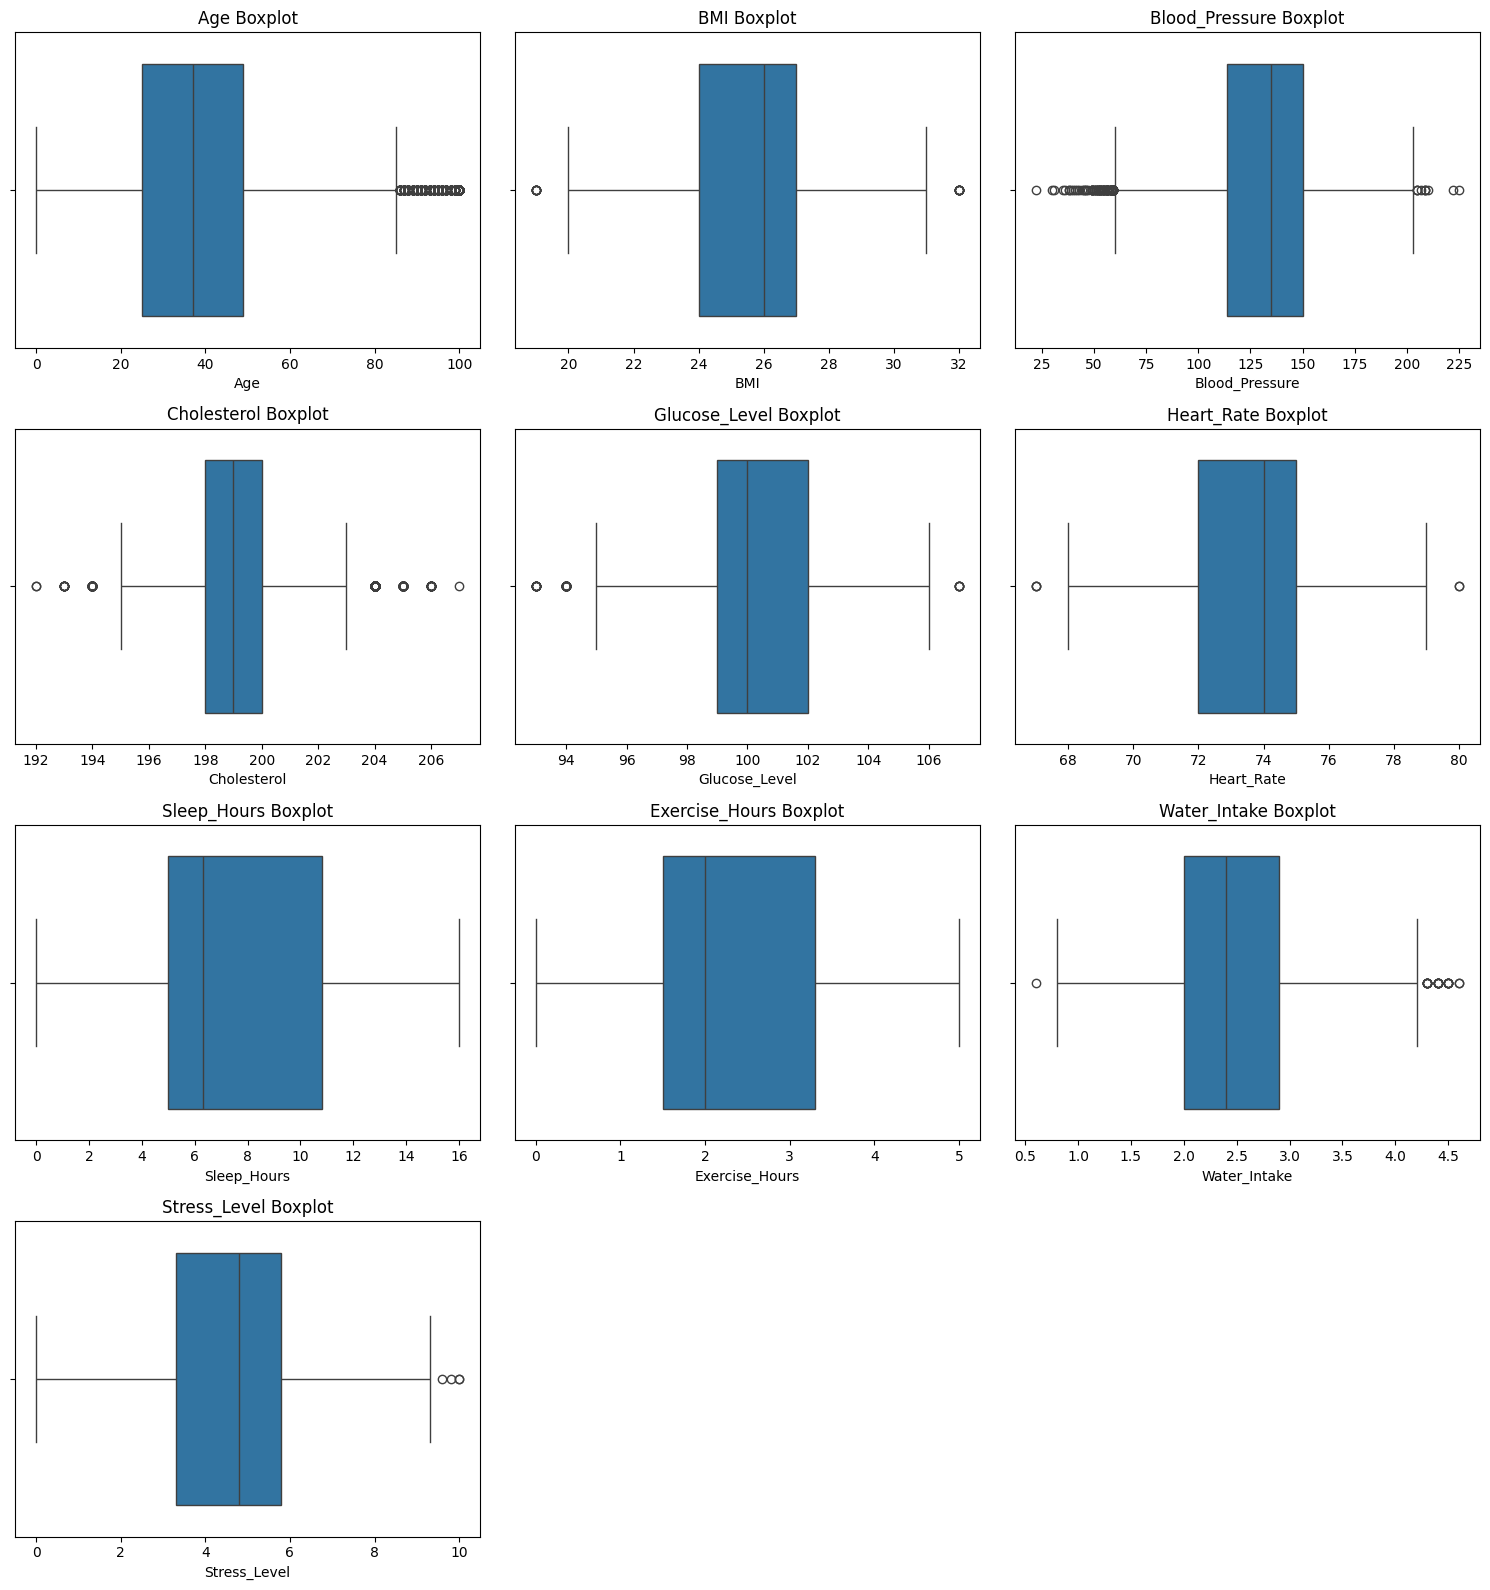

In [61]:
plt.figure(figsize=(num_cols * 5, num_rows * 4))

for i, col in enumerate(numerical_features):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.boxplot(x=df[col])
    plt.title(f'{col} Boxplot')
    plt.xlabel(col)

plt.tight_layout()
plt.show()

**2.1.2 Categorical Feature Analysis**

In [62]:
categorical_features = [
    'Smoking',
    'Alcohol',
    'Diet',
    'MentalHealth',
    'PhysicalActivity',
    'MedicalHistory',
    'Allergies'
]

# Calculate the number of rows and columns for the subplots
num_features = len(categorical_features)
num_cols = 3  # You can adjust this number
num_rows = (num_features + num_cols - 1) // num_cols

**Countplot**

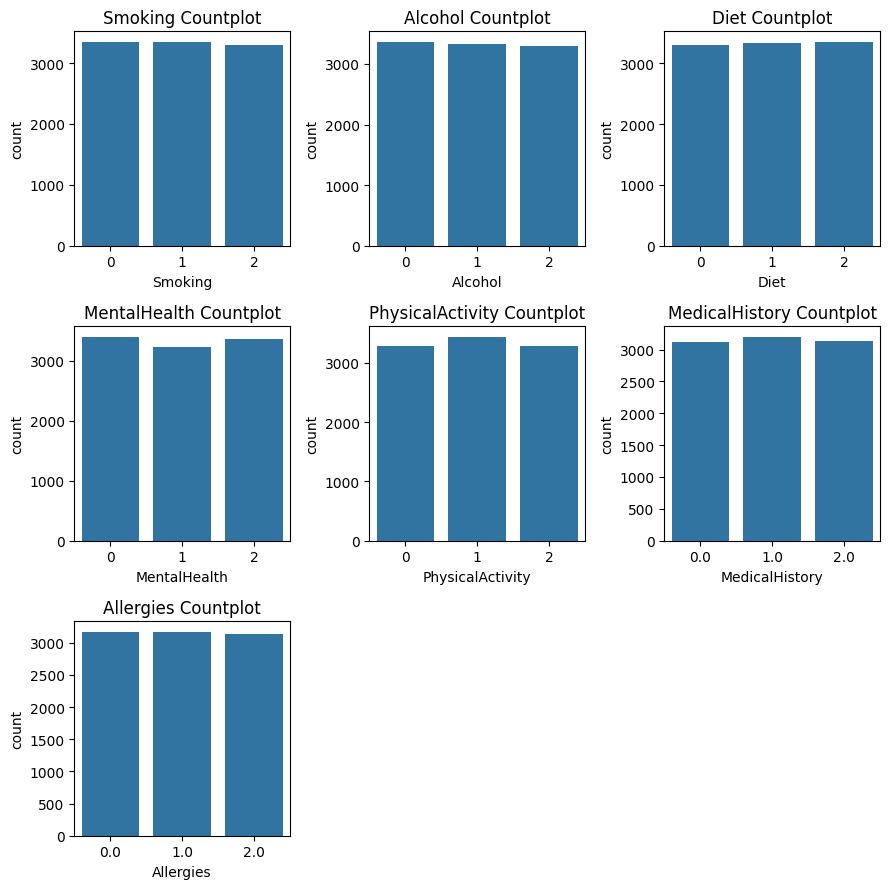

In [71]:
plt.figure(figsize=(num_cols * 3, num_rows * 3))

for i, col in enumerate(categorical_features):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.countplot(x=df[col], data=df)
    plt.title(f'{col} Countplot')
    plt.xlabel(col)

plt.tight_layout()
plt.show()

**2.2 Bivariate Analysis**

**Box Plot**

In [74]:
numerical_features = [
    'Age', 'BMI', 'Blood_Pressure', 'Cholesterol', 'Glucose_Level', 'Stress_Level']

# Calculate the number of rows and columns for the subplots
num_features = len(numerical_features)
num_cols = 3  # You can adjust this number
num_rows = (num_features + num_cols - 1) // num_cols

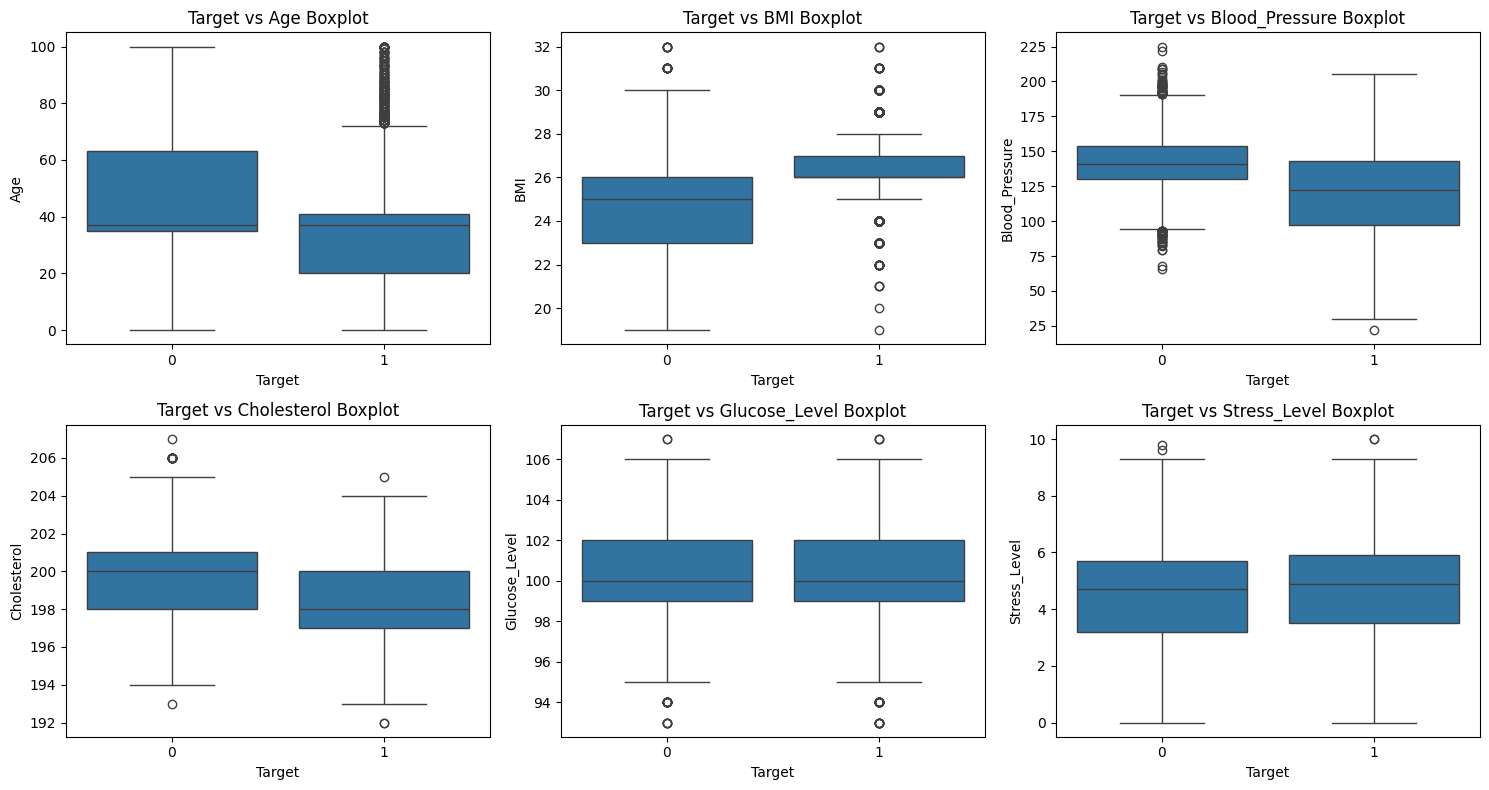

In [77]:
plt.figure(figsize=(num_cols * 5, num_rows * 4))

for i, col in enumerate(numerical_features):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.boxplot(x="Target", y=df[col], data=df)
    plt.title(f'Target vs {col} Boxplot')
    plt.xlabel("Target")
    plt.ylabel(col)

plt.tight_layout()
plt.show()

**Count Plot**

In [78]:
categorical_features = [
    'Smoking', 'Alcohol', 'PhysicalActivity',
]

# Calculate the number of rows and columns for the subplots
num_features = len(categorical_features)
num_cols = 3  # You can adjust this number
num_rows = (num_features + num_cols - 1) // num_cols

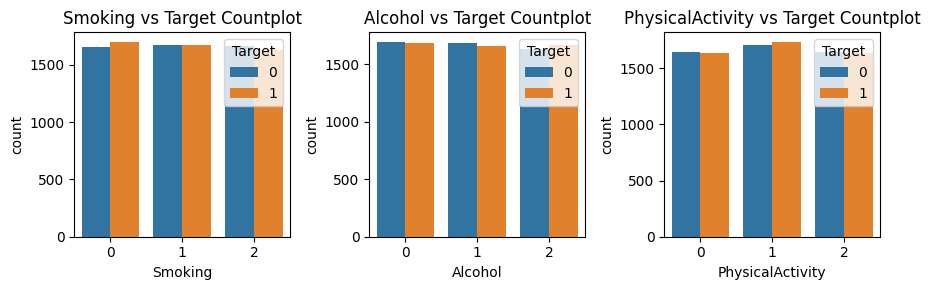

In [79]:
plt.figure(figsize=(num_cols * 3, num_rows * 3))

for i, col in enumerate(categorical_features):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.countplot(x=df[col], hue="Target", data=df)
    plt.title(f'{col} vs Target Countplot')
    plt.xlabel(col)

plt.tight_layout()
plt.show()

**2.3 Correlation Analysis**

In [80]:
df.corr(numeric_only=True)["Target"].sort_values(ascending=False)

,Target
Target,1.000000
BMI,0.372972
Stress_Level,0.059825
Diet_Type_Vegan,0.020333
Blood_Group_B,0.010009
Diet,0.006986
Alcohol,0.005755
PhysicalActivity,-0.000247
Blood_Group_AB,-0.000351
MedicalHistory,-0.002755


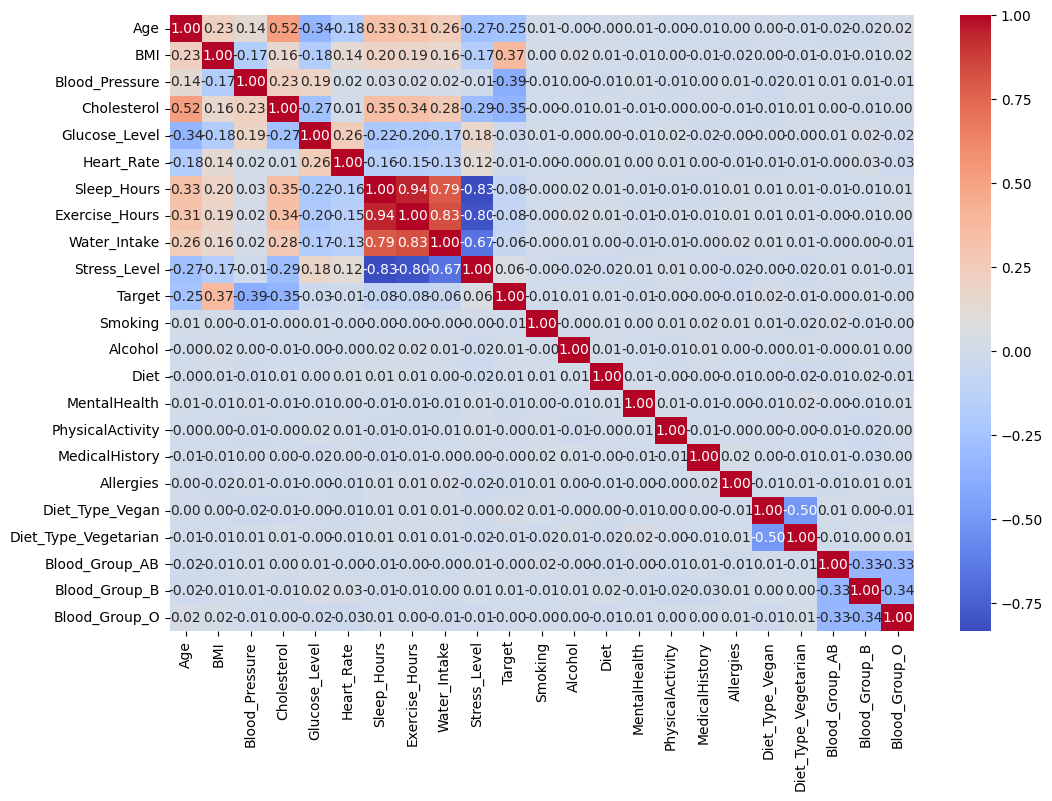

In [81]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")
plt.show()

**Key Findings from EDA**

*   BMI exhibits the strongest positive relationship with health risk (r = 0.373).

*   Blood Pressure (r = -0.387), Cholesterol (r = -0.352), and Age (r = -0.247) show moderate negative correlations with the target variable.
*   Stress Level shows a weak positive correlation (r = 0.060).
*   Lifestyle variables such as Smoking and Alcohol exhibit very weak correlations with health status.
*   Most categorical variables demonstrate limited standalone predictive power.

*   The target variable appears to be influenced primarily by a small subset of numerical features.












In [82]:
df[df["Age"] == 0]["Target"].value_counts()

,count
Target,
1,51
0,45


# **Stage 3 — Data Preprocessing**

**3.1 Create a Working Copy**

In [104]:
df_clean = df.copy()

In [105]:
df_clean.shape

(10000, 23)

**3.2 Remove Invalid Age Records**

During data auditing, 96 records were identified with an Age value of 0. Since an age of zero is not considered a valid value for insurance applicants, these records were treated as invalid observations. The records were removed from the dataset. As they represented less than 1% of the total dataset and were approximately balanced across the target classes, their removal was not expected to introduce significant bias.

In [106]:
df_clean = df_clean[df_clean["Age"] != 0]

In [107]:
df_clean.shape

(9904, 23)

**3.3 Missing Value Treatment**

In [108]:
missing_cols = [
    "Blood_Pressure",
    "Cholesterol",
    "Glucose_Level",
    "MedicalHistory",
    "Allergies"
]

In [109]:
for col in missing_cols:
    print(col)
    print(df_clean[col].describe())
    print()

Blood_Pressure
count    9376.000000
mean      130.972056
std        27.796419
min        22.000000
25%       114.000000
50%       135.000000
75%       150.000000
max       225.000000
Name: Blood_Pressure, dtype: float64

Cholesterol
count    9368.000000
mean      199.201751
std         2.084187
min       192.000000
25%       198.000000
50%       199.000000
75%       200.000000
max       207.000000
Name: Cholesterol, dtype: float64

Glucose_Level
count    9391.000000
mean      100.148334
std         2.207171
min        93.000000
25%        99.000000
50%       100.000000
75%       102.000000
max       107.000000
Name: Glucose_Level, dtype: float64

MedicalHistory
count    9372.000000
mean        1.001280
std         0.813397
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max         2.000000
Name: MedicalHistory, dtype: float64

Allergies
count    9383.000000
mean        0.996376
std         0.815923
min         0.000000
25%         0.000000
50%      

In [110]:
df_clean[missing_cols].agg(["mean", "median"])

,Blood_Pressure,Cholesterol,Glucose_Level,MedicalHistory,Allergies
mean,130.972056,199.201751,100.148334,1.00128,0.996376
median,135.000000,199.000000,100.000000,1.00000,1.000000


In [114]:
missing_before = df_clean.isnull().sum()
missing_before

,0
Age,0
BMI,0
Blood_Pressure,0
Cholesterol,0
Glucose_Level,0
Heart_Rate,0
Sleep_Hours,0
Exercise_Hours,0
Water_Intake,0
Stress_Level,0


| Feature        | Imputation |
| -------------- | ---------- |
| Blood_Pressure | Median     |
| Cholesterol    | Median     |
| Glucose_Level  | Median     |
| MedicalHistory | Mode       |
| Allergies      | Mode       |


In [122]:
df_clean["Blood_Pressure"].median()

135.0

In [115]:
df_clean["Blood_Pressure"] = df_clean["Blood_Pressure"].fillna(df_clean["Blood_Pressure"].median())

df_clean["Cholesterol"] = df_clean["Cholesterol"].fillna(df_clean["Cholesterol"].median())

df_clean["Glucose_Level"] = df_clean["Glucose_Level"].fillna(df_clean["Glucose_Level"].median())

In [120]:
df_clean["Allergies"].mode()

,Allergies
0,0.0


In [123]:
df_clean["Allergies"].mode()[0]

np.float64(0.0)

In [118]:
df_clean["MedicalHistory"] = df_clean["MedicalHistory"].fillna(df_clean["MedicalHistory"].mode()[0])

df_clean["Allergies"] = df_clean["Allergies"].fillna(df_clean["Allergies"].mode()[0])

In [119]:
missing_after = df_clean.isnull().sum()
missing_after

,0
Age,0
BMI,0
Blood_Pressure,0
Cholesterol,0
Glucose_Level,0
Heart_Rate,0
Sleep_Hours,0
Exercise_Hours,0
Water_Intake,0
Stress_Level,0


In [124]:
df_clean.describe()

,Age,BMI,Blood_Pressure,Cholesterol,Glucose_Level,Heart_Rate,Sleep_Hours,Exercise_Hours,Water_Intake,Stress_Level,Target,Smoking,Alcohol,Diet,MentalHealth,PhysicalActivity,MedicalHistory,Allergies
count,9904.000000,9904.000000,9904.000000,9904.000000,9904.000000,9904.000000,9904.000000,9904.000000,9904.000000,9904.000000,9904.000000,9904.000000,9904.000000,9904.000000,9904.000000,9904.000000,9904.000000,9904.000000
mean,40.617932,25.716377,131.186793,199.190832,100.140650,73.530089,8.080180,2.453433,2.486086,4.481099,0.499596,0.994548,0.993942,1.004544,0.997173,1.000202,1.001212,0.943962
std,24.142125,1.947154,27.060392,2.027513,2.149494,1.725276,4.156954,1.316914,0.629909,1.801526,0.500025,0.815984,0.816474,0.816051,0.822898,0.810414,0.791247,0.824735
min,1.000000,19.000000,22.000000,192.000000,93.000000,67.000000,0.000000,0.000000,0.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,26.000000,24.000000,116.000000,198.000000,99.000000,72.000000,5.000000,1.500000,2.000000,3.300000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,37.000000,26.000000,135.000000,199.000000,100.000000,74.000000,6.300000,2.000000,2.400000,4.800000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
75%,50.000000,27.000000,149.000000,200.000000,102.000000,75.000000,10.900000,3.300000,2.900000,5.800000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
max,100.000000,32.000000,225.000000,207.000000,107.000000,80.000000,16.000000,5.000000,4.600000,10.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000


# **Stage 4 — Model Building**

In [141]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

**4.1 Feature Selection**

In [125]:
X = df_clean.drop("Target", axis=1)
y = df_clean["Target"]

In [126]:
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (9904, 22)
Target Shape: (9904,)


**4.2 Train-Test Split**

In [127]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [128]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (7923, 22)
X_test : (1981, 22)
y_train: (7923,)
y_test : (1981,)


**4.3 Feature Scaling**

In [129]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [130]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(7923, 22)
(1981, 22)


**4.4 Logistic Regression Model**

In [133]:
lr_model = LogisticRegression(random_state=42)

lr_model.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [134]:
print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


**4.5 Model Prediction**

In [135]:
y_pred = lr_model.predict(X_test_scaled)

In [136]:
print(y_pred[:10])

[1 1 1 0 1 0 0 1 1 1]


**4.6 Model Evaluation**

Accuracy Score

In [137]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.7774


Confusion Matrix

In [138]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[784 207]
 [234 756]]


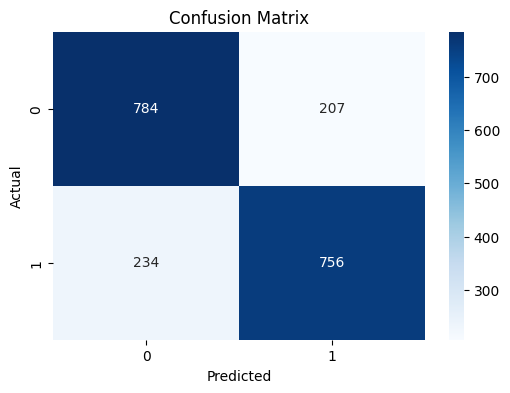

In [139]:
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Classification Report

In [140]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.79      0.78       991
           1       0.79      0.76      0.77       990

    accuracy                           0.78      1981
   macro avg       0.78      0.78      0.78      1981
weighted avg       0.78      0.78      0.78      1981



The Logistic Regression model achieved an accuracy of 78% on the test dataset. Performance was balanced across both classes, with F1-scores of 0.78 for healthy applicants and 0.77 for unhealthy applicants. The model demonstrated reasonable predictive capability and serves as a strong baseline for comparison with more advanced tree-based algorithms.

# **Stage 5 — Decision Tree Classifier**

In [142]:
from sklearn.tree import DecisionTreeClassifier

**5.1 Train Decision Tree Model**

In [143]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [150]:
print("Training Accuracy:",
      dt_model.score(X_train, y_train))

print("Testing Accuracy:",
      dt_model.score(X_test, y_test))

Training Accuracy: 1.0
Testing Accuracy: 0.8061585058051489


**5.2 Generate Predictions**

In [144]:
y_pred_dt = dt_model.predict(X_test)

**5.3 Model Evaluation**

Accuracy Score

In [145]:
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print(f"Decision Tree Accuracy: {dt_accuracy:.4f}")

Decision Tree Accuracy: 0.8062


Confusion Matrix

In [146]:
dt_cm = confusion_matrix(y_test, y_pred_dt)

print(dt_cm)

[[802 189]
 [195 795]]


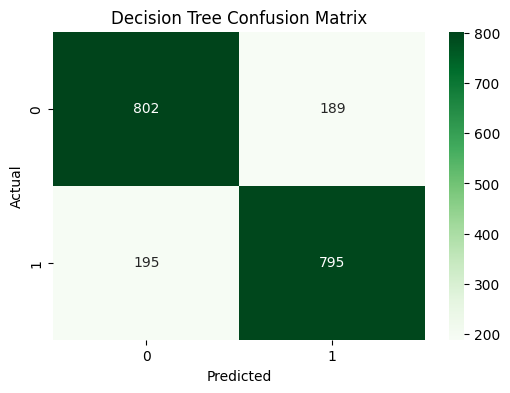

In [147]:
plt.figure(figsize=(6,4))

sns.heatmap(
    dt_cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Classification Report

In [148]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.80      0.81      0.81       991
           1       0.81      0.80      0.81       990

    accuracy                           0.81      1981
   macro avg       0.81      0.81      0.81      1981
weighted avg       0.81      0.81      0.81      1981



**5.4 Compare with Logistic Regression**

In [149]:
comparison = {
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [
        accuracy,
        dt_accuracy
    ]
}

import pandas as pd

pd.DataFrame(comparison)

,Model,Accuracy
0,Logistic Regression,0.777385
1,Decision Tree,0.806159


The Decision Tree classifier achieved a test accuracy of 80.6%, outperforming Logistic Regression (78%). However, the model achieved 100% training accuracy, indicating significant overfitting. While the tree captured additional non-linear relationships in the data, its generalization ability may be improved through pruning or ensemble methods.

# **Stage 6 — Random Forest Classifier**

Random Forest builds multiple Decision Trees and combines their predictions.

Advantages:

* Reduces overfitting
* Better generalization
* More robust than a single tree
* Provides feature importance

In [151]:
from sklearn.ensemble import RandomForestClassifier

**6.1 Train Random Forest Model**

In [152]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [153]:
print("Random Forest model trained successfully.")

Random Forest model trained successfully.


**6.2 Generate Predictions**

In [154]:
y_pred_rf = rf_model.predict(X_test)

**6.3 Model Evaluation**

Accuracy Score

In [155]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print(f"Random Forest Accuracy: {rf_accuracy:.4f}")

Random Forest Accuracy: 0.8561


In [156]:
print("Training Accuracy:",
      rf_model.score(X_train, y_train))

print("Testing Accuracy:",
      rf_model.score(X_test, y_test))

Training Accuracy: 1.0
Testing Accuracy: 0.8561332660272589


Confusion Matrix

In [157]:
rf_cm = confusion_matrix(y_test, y_pred_rf)

print(rf_cm)

[[840 151]
 [134 856]]


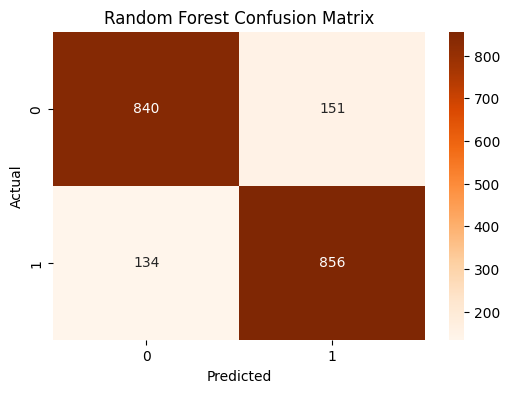

In [158]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Classification Report

In [ ]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.86      0.85      0.85       991
           1       0.85      0.86      0.86       990

    accuracy                           0.86      1981
   macro avg       0.86      0.86      0.86      1981
weighted avg       0.86      0.86      0.86      1981



# **Stage 7 — Model Comparison & Final Selection**

**7.1 Accuracy Comparison**

In [162]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        dt_accuracy,
        rf_accuracy
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.777385
1,Decision Tree,0.806159
2,Random Forest,0.856133


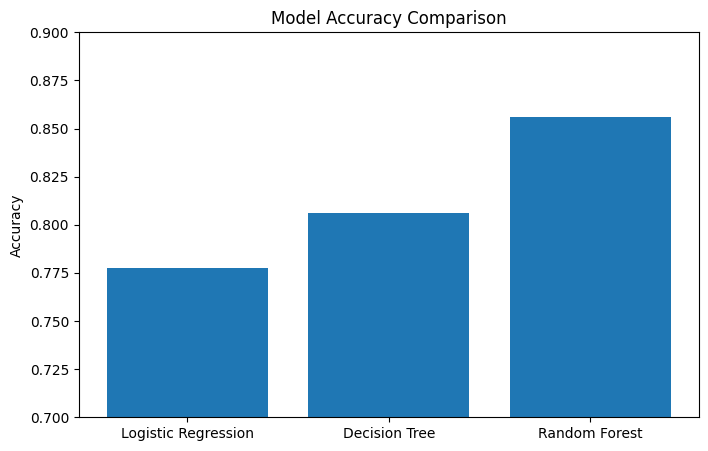

In [163]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0.7, 0.9)

plt.show()

**7.2 ROC-AUC Comparison**

**Why ROC-AUC?**

Accuracy measures performance at one threshold.

ROC-AUC evaluates performance across all classification thresholds.

**Generate Probabilities**

Logistic Regression

In [164]:
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

Decision Tree

In [165]:
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

Random Forest

In [166]:
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

**Compute ROC Curves**

In [167]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

**Compute AUC Scores**

In [168]:
auc_lr = roc_auc_score(y_test, y_prob_lr)
auc_dt = roc_auc_score(y_test, y_prob_dt)
auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Logistic Regression AUC:", auc_lr)
print("Decision Tree AUC:", auc_dt)
print("Random Forest AUC:", auc_rf)

Logistic Regression AUC: 0.8617425516517342
Decision Tree AUC: 0.8061569274990062
Random Forest AUC: 0.9375602646036552


**Plot ROC Curves**

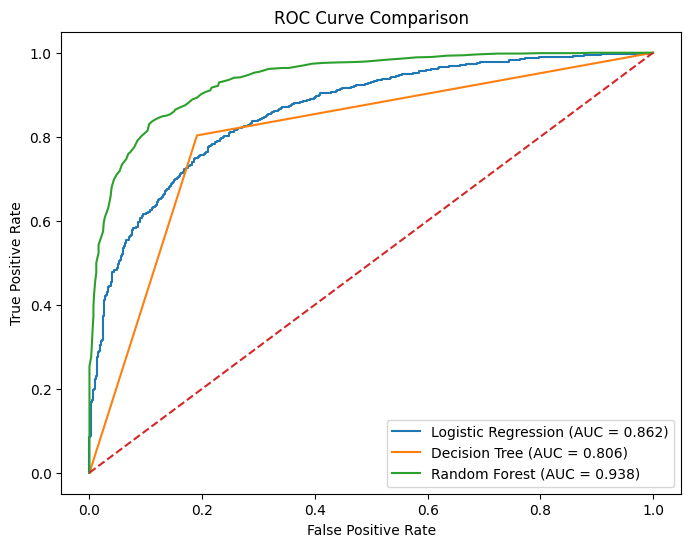

In [169]:
plt.figure(figsize=(8,6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {auc_lr:.3f})"
)

plt.plot(
    fpr_dt,
    tpr_dt,
    label=f"Decision Tree (AUC = {auc_dt:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {auc_rf:.3f})"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

**7.3 Learning Curve Analysis (Random Forest)**

In [170]:
from sklearn.model_selection import learning_curve

In [171]:
train_sizes, train_scores, val_scores = learning_curve(
    rf_model,
    X,
    y,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

Compute Means

In [172]:
train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

Plot Learning Curve

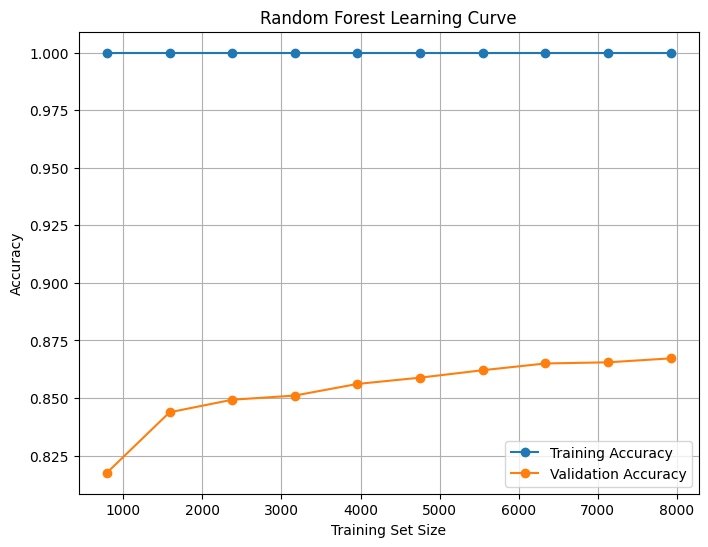

In [173]:
plt.figure(figsize=(8,6))

plt.plot(
    train_sizes,
    train_mean,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    train_sizes,
    val_mean,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Random Forest Learning Curve")

plt.legend()

plt.grid(True)

plt.show()

**7.4 Feature Importance Analysis**

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
1,BMI,0.185629
2,Blood_Pressure,0.174761
3,Cholesterol,0.114391
0,Age,0.084577
4,Glucose_Level,0.070583
5,Heart_Rate,0.054866
6,Sleep_Hours,0.049132
9,Stress_Level,0.045283
8,Water_Intake,0.040518
7,Exercise_Hours,0.040145


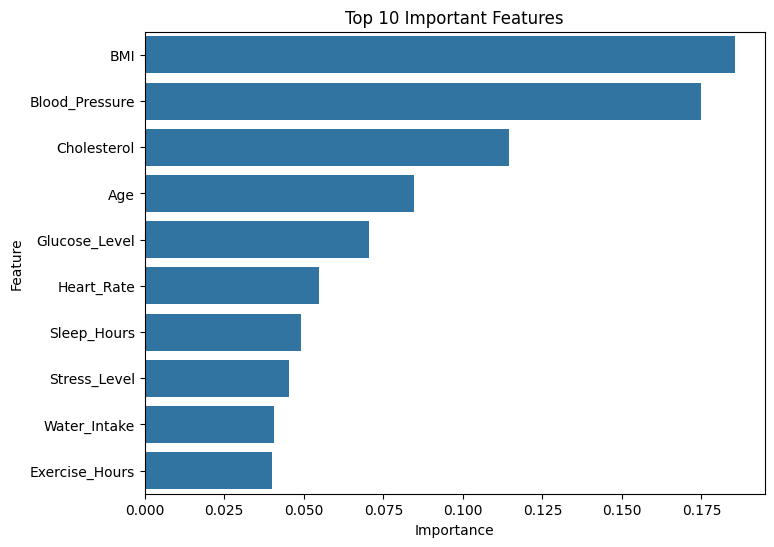

In [ ]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")
plt.show()

Three classification algorithms were evaluated for health-risk prediction: Logistic Regression, Decision Tree, and Random Forest. Random Forest achieved the highest performance with an accuracy of 85.6% and an ROC-AUC score of 0.938. Learning curve analysis showed strong generalization performance, while feature importance analysis identified BMI, Blood Pressure, Cholesterol, Age, and Glucose Level as the most influential predictors. Based on these results, Random Forest was selected as the final model for insurance health-risk classification.

# Stage 8 — Business Recommendations

Based on the analysis and model results, several insights can support insurance premium pricing and risk assessment decisions.

## 8.1 Risk-Based Premium Pricing

The Random Forest model identified BMI, Blood Pressure, Cholesterol, Age, and Glucose Level as the most influential factors affecting health risk classification.

Applicants exhibiting higher-risk profiles in these features may be considered for:
- Higher premium plans
- Additional medical screening
- Periodic health monitoring requirements

Conversely, applicants with favorable health indicators may qualify for lower premium rates and incentive programs.

---

## 8.2 Early Risk Identification

The developed classification model can be integrated into the insurance underwriting process to identify potentially unhealthy applicants during the application stage.

This enables:
- Faster decision-making
- Consistent risk assessment
- Reduced dependence on manual evaluation

---

## 8.3 Personalized Health Programs

The model highlights lifestyle and physiological factors associated with health outcomes.

Insurance providers may use these insights to design:
- Wellness programs
- Preventive healthcare initiatives
- Fitness and nutrition incentives

Such programs may help reduce long-term healthcare costs and claim frequencies.

---

## 8.4 Data-Driven Underwriting

The machine learning approach provides an objective and scalable mechanism for evaluating applicant health status.

Compared to purely manual assessments, data-driven underwriting can:
- Improve consistency
- Reduce subjectivity
- Support large-scale application processing

---

## 8.5 Continuous Model Improvement

As more applicant data becomes available, the model can be periodically retrained to improve predictive performance and adapt to changing health trends.

Future enhancements may include:
- Additional medical indicators
- Longitudinal health records
- Explainable AI techniques for decision transparency

# Stage 9 — Conclusion

## Project Summary

The objective of this project was to develop a machine learning model capable of classifying insurance applicants as Healthy or Unhealthy based on demographic, lifestyle, and medical attributes. The resulting classification can support insurance premium pricing and risk assessment decisions.

---

## Data Preparation

The dataset initially contained 10,000 records and 23 features.

Several preprocessing steps were performed:

- Removed 96 records containing invalid Age values equal to zero.
- Handled missing values using median and mode imputation techniques.
- Verified the absence of duplicate records.
- Prepared a clean dataset containing 9,904 observations for model development.

---

## Exploratory Data Analysis

Exploratory analysis revealed several important findings:

- BMI exhibited the strongest positive relationship with health risk.
- Blood Pressure, Cholesterol, Age, and Glucose Level showed meaningful associations with the target variable.
- Most categorical variables demonstrated relatively weak standalone predictive power.
- The target classes were nearly perfectly balanced, eliminating concerns related to class imbalance.

---

## Model Development and Evaluation

Three classification algorithms were evaluated:

| Model | Accuracy |
|---------|---------:|
| Logistic Regression | 78.0% |
| Decision Tree | 80.6% |
| Random Forest | 85.6% |

Performance was further assessed using ROC-AUC analysis:

| Model | ROC-AUC |
|---------|---------:|
| Logistic Regression | 0.862 |
| Decision Tree | 0.806 |
| Random Forest | 0.938 |

The Random Forest classifier consistently outperformed the other models across all evaluation metrics.

---

## Feature Importance Analysis

Feature importance analysis identified the following variables as the most influential predictors:

1. BMI
2. Blood Pressure
3. Cholesterol
4. Age
5. Glucose Level

These features contributed most significantly to distinguishing healthy and unhealthy applicants.

---

## Final Model Selection

The Random Forest classifier was selected as the final model because it achieved:

- Highest accuracy (85.6%)
- Highest ROC-AUC score (0.938)
- Balanced precision and recall across both classes
- Strong predictive performance and robustness

Learning curve analysis further demonstrated good generalization capability while indicating that additional training data may yield further performance improvements.

---

## Future Scope

Potential future enhancements include:

- Hyperparameter tuning of ensemble models
- Integration of additional health indicators
- Deployment as a real-time underwriting support system
- Implementation of Explainable AI techniques such as SHAP for greater interpretability
- Continuous retraining using updated applicant data

---

## Final Remark

This project successfully demonstrated the application of machine learning techniques for insurance health-risk classification. The developed Random Forest model provides a reliable and scalable framework for supporting insurance underwriting decisions and premium pricing strategies through data-driven risk assessment.